# 11B — Pedi-CGAM Lite: Reliability-Gated Local Residual Fusion — Seed 42

**Project:** Pedi-CGAM Lite  
**Experiment ID:** `M10_PediCGAMLite_GatedLocalResidual_Seed42`  
**Platform:** Kaggle  
**Target GPU:** NVIDIA T4  

## Why 11B is needed

11A was technically valid, but the adaptive fusion weight collapsed close to zero while the learned residual branch could still perturb the strong 09A prediction.

That revealed a design mismatch:

> In 11A, `gate → 0` did **not** guarantee `final prediction → exact 09A prediction`.

11B fixes that directly.

## New fusion rule

```text
Frozen 09A disease logits
            │
            ├───────────────────────────────┐
            │                               │
            │                    Frozen 10E lesion feature
            │                               │
            │                       local residual head
            │                               │
            │                    reliability-guided gate
            │                               │
            └──────────── + gate × local residual
                                            ↓
                                      final logits
```

The equation is:

**`final_logits = frozen_09A_logits + gate × local_residual_logits`**

This gives the behavior we actually want:

- if `gate ≈ 0` → the prediction falls back to **exact 09A**;
- if local lesion evidence is useful → the gate can increase and allow a local correction.

## Frozen components 🔒

- 09A / M01 ResNet50 backbone
- 09A disease head
- 09A finding head
- 10E / M08 localization adapter

## Trainable components 🧪

Only:

1. a scalar reliability-guided gate;
2. a small **local-only disease residual head**.

The residual head is initialized to zero.

Therefore, before training:

> **11B predictions are exactly the 09A predictions.**

## Gate inputs

The gate sees:

- normalized global feature;
- normalized lesion-focused feature;
- maximum abnormal-finding probability;
- mean abnormal-finding probability;
- top-3 mean abnormal-finding probability;
- spatial attention concentration.

The gate remains an **adaptive fusion weight / reliability signal**, not a calibrated confidence probability.

## Important methodological safeguard: epoch 0

11B explicitly records **epoch 0 = exact 09A baseline** as a checkpoint candidate.

A trained epoch replaces it only if validation **14-pathology Macro-AUPRC** is higher.

So the selected 11B checkpoint can never be worse than the exact baseline simply because training perturbed the residual branch.

## Main scientific question

> Can reliable lesion-focused evidence provide an optional disease correction that improves on 09A while preserving an exact global fallback?

This is a controlled architectural correction to 11A, not a broad hyperparameter sweep.


In [1]:
# ============================================================
# 1. Install DICOM decoders
# ============================================================
%pip install -q -U "pylibjpeg[all]" pyjpegls

print("✅ DICOM decoder packages ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.3/272.3 kB 18.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
✅ DICOM decoder packages ready.


In [2]:
# ============================================================
# 2. Imports + frozen configuration
# ============================================================
import os
import sys
import gc
import io
import json
import time
import math
import random
import hashlib
import zipfile
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydicom
from pydicom.pixels import apply_modality_lut, apply_voi_lut
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from torchvision.models import resnet50

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    recall_score,
    confusion_matrix,
)

from tqdm.auto import tqdm

EXPERIMENT_ID = "M10_PediCGAMLite_GatedLocalResidual_Seed42"
BASELINE_EXPERIMENT_ID = "M01_DiseaseFinding_Multitask_Seed42"
LOCALIZATION_EXPERIMENT_ID = "M08_DecoupledLocalizationAdapter_Seed42"

SEED = 42
IMAGE_SIZE = 320
BOX_MASK_SIZE = 80

BATCH_SIZE = 8
NUM_WORKERS = 4

MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5

FUSION_LR = 1e-4
FUSION_WEIGHT_DECAY = 1e-4
FOCAL_GAMMA = 2.0

FIXED_THRESHOLD = 0.5
USE_AMP = True

EXPECTED_M01_PATHOLOGY14_AUPRC = 0.208471
M01_REPRO_TOLERANCE = 5e-4

EXPECTED_SPLIT_MANIFEST_SHA256 = (
    "3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770"
)

OUTPUT_DIR = Path(f"/kaggle/working/PediCGAM/{EXPERIMENT_ID}")
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
CACHE_DIR = Path(
    f"/kaggle/working/PediCGAM_cache/{EXPERIMENT_ID}_{IMAGE_SIZE}"
)

for d in [OUTPUT_DIR, TABLE_DIR, FIG_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Notebook build: 11B_GATED_LOCAL_RESIDUAL_V1")
print("Experiment:", EXPERIMENT_ID)
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("pydicom:", pydicom.__version__)
print("Device:", DEVICE)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "GPU is not active. Enable a Kaggle GPU accelerator before running 11B."
    )

print("GPU:", torch.cuda.get_device_name(0))
print(
    "GPU memory:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB",
)


Notebook build: 11B_GATED_LOCAL_RESIDUAL_V1
Experiment: M10_PediCGAMLite_GatedLocalResidual_Seed42
Python: 3.12.13
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
pydicom: 3.0.2
Device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB


# 3. Required Kaggle inputs

Attach **four inputs**:

1. **VinDr-PCXR**
2. **Stage-02 frozen split output**
3. **09A / M01 output** containing `best_model.pth`
4. **10E / M08 output** containing `best_localization_adapter.pth`

You do **not** need 10A, 10B, 10C, or 10D.

The calibration split and official test remain untouched.


In [3]:
# ============================================================
# 4. Locate VinDr-PCXR
# ============================================================
KAGGLE_INPUT = Path("/kaggle/input")

def find_vindr_root(search_root=KAGGLE_INPUT):
    candidates = []

    for f in search_root.rglob("image_labels_train.csv"):
        folder = f.parent
        names = {
            p.name
            for p in folder.iterdir()
            if p.is_file()
        }

        score = sum(
            name in names
            for name in [
                "image_labels_train.csv",
                "annotations_train.csv",
            ]
        )

        candidates.append((score, folder))

    candidates.sort(
        key=lambda x: (-x[0], len(str(x[1])))
    )

    return candidates

vindr_candidates = find_vindr_root()

if not vindr_candidates:
    raise FileNotFoundError(
        "VinDr-PCXR was not found under /kaggle/input."
    )

DATA_ROOT = vindr_candidates[0][1]
TRAIN_DICOM_DIR = DATA_ROOT / "train"

if not TRAIN_DICOM_DIR.exists():
    raise FileNotFoundError(
        f"Training DICOM directory not found: {TRAIN_DICOM_DIR}"
    )

print("VinDr-PCXR root:")
print(DATA_ROOT)
print("\nTraining DICOM directory:")
print(TRAIN_DICOM_DIR)


VinDr-PCXR root:
/kaggle/input/datasets/kalloldaskushol/vindr-pcxr/Pediatric Chest X-ray/physionet.org/files/vindr-pcxr/1.0.0

Training DICOM directory:
/kaggle/input/datasets/kalloldaskushol/vindr-pcxr/Pediatric Chest X-ray/physionet.org/files/vindr-pcxr/1.0.0/train


In [4]:
# ============================================================
# 5. Locate + verify frozen Stage-02 split
# ============================================================
def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)

    return h.hexdigest()


def find_frozen_manifest(search_root=KAGGLE_INPUT):
    for p in search_root.rglob("fixed_split_manifest.csv"):
        if sha256_file(p) == EXPECTED_SPLIT_MANIFEST_SHA256:
            return p, "direct_csv", None

    for zip_path in search_root.rglob("*.zip"):
        try:
            with zipfile.ZipFile(zip_path, "r") as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith("fixed_split_manifest.csv")
                ]

                for member in members:
                    raw = zf.read(member)
                    digest = hashlib.sha256(raw).hexdigest()

                    if digest == EXPECTED_SPLIT_MANIFEST_SHA256:
                        temp = Path(
                            "/kaggle/working/stage02_manifest_11a.csv"
                        )
                        temp.write_bytes(raw)
                        return temp, "zip", zip_path
        except zipfile.BadZipFile:
            pass

    return None, None, None


MANIFEST_PATH, MANIFEST_SOURCE, MANIFEST_CONTAINER = find_frozen_manifest()

if MANIFEST_PATH is None:
    raise FileNotFoundError(
        "Frozen Stage-02 split was not found."
    )

manifest_hash = sha256_file(MANIFEST_PATH)

if manifest_hash != EXPECTED_SPLIT_MANIFEST_SHA256:
    raise RuntimeError(
        "STOP: Stage-02 split SHA-256 mismatch."
    )

print("Manifest:", MANIFEST_PATH)
print("Source:", MANIFEST_SOURCE)
print("SHA-256:", manifest_hash)
print("✅ FROZEN STAGE-02 SPLIT VERIFIED.")


Manifest: /kaggle/input/notebooks/kalloldaskushol/02-fixed-train-validation-calibration-split/PediCGAM/stage02_fixed_split/splits/fixed_split_manifest.csv
Source: direct_csv
SHA-256: 3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770
✅ FROZEN STAGE-02 SPLIT VERIFIED.


In [5]:
# ============================================================
# 6. Locate + verify executed 09A / M01 checkpoint
# ============================================================
M01_EXTRACT_DIR = Path("/kaggle/working/m01_11a_extracted")
M01_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

def checkpoint_matches_m01(path):
    try:
        ckpt = torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )

        return (
            ckpt.get("experiment_id") == BASELINE_EXPERIMENT_ID
            and np.isclose(
                float(ckpt.get("finding_loss_weight")),
                0.5,
            )
            and ckpt.get("boxes_used") is False
            and ckpt.get("split_manifest_sha256")
            == EXPECTED_SPLIT_MANIFEST_SHA256
        )
    except Exception:
        return False


M01_CHECKPOINT_PATH = None
M01_CHECKPOINT_SOURCE = None

for p in KAGGLE_INPUT.rglob("best_model.pth"):
    if checkpoint_matches_m01(p):
        M01_CHECKPOINT_PATH = p
        M01_CHECKPOINT_SOURCE = "direct"
        break

if M01_CHECKPOINT_PATH is None:
    for zip_path in KAGGLE_INPUT.rglob("*.zip"):
        try:
            with zipfile.ZipFile(zip_path, "r") as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith("/best_model.pth") or n == "best_model.pth"
                ]

                for member in members:
                    target = M01_EXTRACT_DIR / "candidate_best_model.pth"
                    target.write_bytes(zf.read(member))

                    if checkpoint_matches_m01(target):
                        M01_CHECKPOINT_PATH = target
                        M01_CHECKPOINT_SOURCE = f"zip:{zip_path.name}"
                        break

                if M01_CHECKPOINT_PATH is not None:
                    break
        except zipfile.BadZipFile:
            pass

if M01_CHECKPOINT_PATH is None:
    raise FileNotFoundError(
        "Executed 09A / M01 best_model.pth was not found."
    )

m01_checkpoint = torch.load(
    M01_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

print("✅ 09A / M01 checkpoint verified")
print("Checkpoint:", M01_CHECKPOINT_PATH)
print("Source:", M01_CHECKPOINT_SOURCE)
print("Epoch:", m01_checkpoint.get("epoch"))
print(
    "Stored selection metric:",
    m01_checkpoint.get("selection_metric_value"),
)


✅ 09A / M01 checkpoint verified
Checkpoint: /kaggle/input/notebooks/kalloldaskushol/09a-disease-and-finding-multitask-seed42-fixed/PediCGAM/M01_DiseaseFinding_Multitask_Seed42/best_model.pth
Source: direct
Epoch: 4
Stored selection metric: 0.20847144131991252


In [6]:
# ============================================================
# 7. Locate + verify executed 10E / M08 localization adapter
# ============================================================
M08_EXTRACT_DIR = Path("/kaggle/working/m08_11a_extracted")
M08_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

def checkpoint_matches_m08(path):
    try:
        ckpt = torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )

        return (
            ckpt.get("experiment_id") == LOCALIZATION_EXPERIMENT_ID
            and ckpt.get("base_experiment_id") == BASELINE_EXPERIMENT_ID
            and ckpt.get("base_model_frozen") is True
            and ckpt.get("feature_maps_detached") is True
            and ckpt.get("split_manifest_sha256")
            == EXPECTED_SPLIT_MANIFEST_SHA256
        )
    except Exception:
        return False


M08_CHECKPOINT_PATH = None
M08_CHECKPOINT_SOURCE = None

for p in KAGGLE_INPUT.rglob("best_localization_adapter.pth"):
    if checkpoint_matches_m08(p):
        M08_CHECKPOINT_PATH = p
        M08_CHECKPOINT_SOURCE = "direct"
        break

if M08_CHECKPOINT_PATH is None:
    for zip_path in KAGGLE_INPUT.rglob("*.zip"):
        try:
            with zipfile.ZipFile(zip_path, "r") as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith("/best_localization_adapter.pth")
                    or n == "best_localization_adapter.pth"
                ]

                for member in members:
                    target = (
                        M08_EXTRACT_DIR
                        / "candidate_best_localization_adapter.pth"
                    )
                    target.write_bytes(zf.read(member))

                    if checkpoint_matches_m08(target):
                        M08_CHECKPOINT_PATH = target
                        M08_CHECKPOINT_SOURCE = f"zip:{zip_path.name}"
                        break

                if M08_CHECKPOINT_PATH is not None:
                    break
        except zipfile.BadZipFile:
            pass

if M08_CHECKPOINT_PATH is None:
    raise FileNotFoundError(
        "Executed 10E / M08 best_localization_adapter.pth was not found."
    )

m08_checkpoint = torch.load(
    M08_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

print("✅ 10E / M08 localization adapter verified")
print("Checkpoint:", M08_CHECKPOINT_PATH)
print("Source:", M08_CHECKPOINT_SOURCE)
print("Epoch:", m08_checkpoint.get("epoch"))
print(
    "Stored localization mass:",
    m08_checkpoint.get("localization_selection_metric_value"),
)
print(
    "Stored pointing-game accuracy:",
    m08_checkpoint.get("localization_pointing_game_accuracy"),
)


✅ 10E / M08 localization adapter verified
Checkpoint: /kaggle/input/notebooks/kalloldaskushol/10e-decoupled-box-localization-adapter-seed42/PediCGAM/M08_DecoupledLocalizationAdapter_Seed42/best_localization_adapter.pth
Source: direct
Epoch: 9
Stored localization mass: 0.6989943536618668
Stored pointing-game accuracy: 0.7422480620155039


In [7]:
# ============================================================
# 8. Load disease labels + frozen split
# ============================================================
labels = pd.read_csv(DATA_ROOT / "image_labels_train.csv")
manifest = pd.read_csv(MANIFEST_PATH)

NON_LABEL_COLUMNS = [
    "image_id",
    "rad_ID",
]

LABEL_COLUMNS = [
    c
    for c in labels.columns
    if c not in NON_LABEL_COLUMNS
]

if len(LABEL_COLUMNS) != 15:
    raise RuntimeError(
        f"Expected 15 disease outputs, found {len(LABEL_COLUMNS)}."
    )

if "No finding" not in LABEL_COLUMNS:
    raise RuntimeError(
        "Disease labels do not contain 'No finding'."
    )

PATHOLOGY_COLUMNS = [
    c
    for c in LABEL_COLUMNS
    if c != "No finding"
]

df = manifest.merge(
    labels,
    on="image_id",
    how="left",
    validate="one_to_one",
)

if df[LABEL_COLUMNS].isna().any().any():
    raise RuntimeError(
        "Some split-manifest images have missing disease labels."
    )

split_counts = df["split"].value_counts()

expected_counts = {
    "train": 5408,
    "validation": 1159,
    "calibration": 1161,
}

for split_name, expected_count in expected_counts.items():
    actual = int(split_counts.get(split_name, -1))
    if actual != expected_count:
        raise RuntimeError(
            f"Frozen {split_name} count is {actual}, expected {expected_count}."
        )

train_df = (
    df[df["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

val_df = (
    df[df["split"] == "validation"]
    .copy()
    .reset_index(drop=True)
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print(
    "Calibration images present but NOT used:",
    int(split_counts["calibration"]),
)


Training images: 5408
Validation images: 1159
Calibration images present but NOT used: 1161


In [8]:
# ============================================================
# 9. Build 37 image-level finding targets from class_name
# ============================================================
annotations = pd.read_csv(DATA_ROOT / "annotations_train.csv")

required_annotation_columns = {
    "image_id",
    "class_name",
    "x_min",
    "y_min",
    "x_max",
    "y_max",
}

missing_cols = required_annotation_columns - set(annotations.columns)

if missing_cols:
    raise RuntimeError(
        "annotations_train.csv is missing: "
        + str(sorted(missing_cols))
    )

annotation_class_names = (
    annotations["class_name"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

FINDING_CLASSES = (
    ["No finding"]
    + sorted(
        x
        for x in annotation_class_names
        if x != "No finding"
    )
)

if len(FINDING_CLASSES) != 37:
    raise RuntimeError(
        f"Expected 37 finding outputs, found {len(FINDING_CLASSES)}."
    )

NO_FINDING_INDEX = FINDING_CLASSES.index("No finding")
ACTUAL_FINDING_INDICES = [
    i
    for i in range(len(FINDING_CLASSES))
    if i != NO_FINDING_INDEX
]

FINDING_TARGET_COLUMNS = [
    f"finding_target_{i:02d}"
    for i in range(len(FINDING_CLASSES))
]

finding_matrix = pd.crosstab(
    annotations["image_id"].astype(str),
    annotations["class_name"].astype(str),
)

finding_matrix = (
    finding_matrix
    .reindex(columns=FINDING_CLASSES, fill_value=0)
    .clip(upper=1)
    .astype(np.float32)
)

df["image_id_str"] = df["image_id"].astype(str)

for target_col, class_name in zip(
    FINDING_TARGET_COLUMNS,
    FINDING_CLASSES,
):
    df[target_col] = (
        df["image_id_str"]
        .map(finding_matrix[class_name])
        .fillna(0)
        .astype(np.float32)
    )

train_df = (
    df[df["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

val_df = (
    df[df["split"] == "validation"]
    .copy()
    .reset_index(drop=True)
)

finding_class_map = pd.DataFrame({
    "finding_index": range(len(FINDING_CLASSES)),
    "class_name": FINDING_CLASSES,
})

finding_class_map.to_csv(
    TABLE_DIR / "finding_class_map.csv",
    index=False,
)

print("Finding outputs:", len(FINDING_CLASSES))
print("Actual abnormal finding outputs:", len(ACTUAL_FINDING_INDICES))
print("Numeric class_id used: NO")


Finding outputs: 37
Actual abnormal finding outputs: 36
Numeric class_id used: NO


In [9]:
# ============================================================
# 10. Build DICOM index
# ============================================================
dicom_paths = {
    p.stem: p
    for p in TRAIN_DICOM_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in {".dicom", ".dcm"}
}

required_ids = (
    set(train_df["image_id"].astype(str))
    | set(val_df["image_id"].astype(str))
)

missing_files = sorted(
    required_ids - set(dicom_paths.keys())
)

print("DICOM files indexed:", len(dicom_paths))
print("Train+validation IDs required:", len(required_ids))
print("Missing files:", len(missing_files))

if missing_files:
    raise FileNotFoundError(
        "Some frozen train/validation DICOM files are missing."
    )

print("✅ All train/validation DICOM files are present.")


DICOM files indexed: 7728
Train+validation IDs required: 6567
Missing files: 0
✅ All train/validation DICOM files are present.


In [10]:
# ============================================================
# 11. Prepare normalized valid boxes for localization audit only
# ============================================================
BOX_COLS = [
    "x_min",
    "y_min",
    "x_max",
    "y_max",
]

box_numeric = annotations[BOX_COLS].apply(
    pd.to_numeric,
    errors="coerce",
)

valid_box_flag = (
    box_numeric.notna().all(axis=1)
    & (box_numeric["x_max"] > box_numeric["x_min"])
    & (box_numeric["y_max"] > box_numeric["y_min"])
    & (box_numeric[BOX_COLS] >= 0).all(axis=1)
)

valid_boxes = annotations.loc[valid_box_flag].copy()

for c in BOX_COLS:
    valid_boxes[c] = box_numeric.loc[valid_box_flag, c].astype(float)

valid_boxes = valid_boxes[
    valid_boxes["class_name"].astype(str) != "No finding"
].copy()

valid_boxes["image_id"] = valid_boxes["image_id"].astype(str)

valid_boxes = valid_boxes[
    valid_boxes["image_id"].isin(required_ids)
].copy()

boxed_ids = sorted(valid_boxes["image_id"].unique().tolist())

dimension_rows = []

for image_id in tqdm(
    boxed_ids,
    desc="Reading boxed-image dimensions",
):
    ds = pydicom.dcmread(
        str(dicom_paths[image_id]),
        stop_before_pixels=True,
        specific_tags=["Rows", "Columns"],
    )

    dimension_rows.append({
        "image_id": image_id,
        "rows": int(ds.Rows),
        "columns": int(ds.Columns),
    })

dimensions_df = pd.DataFrame(dimension_rows)

valid_boxes = valid_boxes.merge(
    dimensions_df,
    on="image_id",
    how="left",
    validate="many_to_one",
)

valid_boxes["nx_min"] = (
    valid_boxes["x_min"] / valid_boxes["columns"]
).clip(0, 1)

valid_boxes["nx_max"] = (
    valid_boxes["x_max"] / valid_boxes["columns"]
).clip(0, 1)

valid_boxes["ny_min"] = (
    valid_boxes["y_min"] / valid_boxes["rows"]
).clip(0, 1)

valid_boxes["ny_max"] = (
    valid_boxes["y_max"] / valid_boxes["rows"]
).clip(0, 1)

post_clip_valid = (
    (valid_boxes["nx_max"] > valid_boxes["nx_min"])
    & (valid_boxes["ny_max"] > valid_boxes["ny_min"])
)

if not post_clip_valid.all():
    raise RuntimeError(
        "At least one box became invalid after normalization/clipping."
    )

finding_to_index = {
    name: i
    for i, name in enumerate(FINDING_CLASSES)
}

BOXES_BY_IMAGE = {}

for image_id, group in valid_boxes.groupby("image_id"):
    items = []

    for row in group.itertuples(index=False):
        items.append((
            finding_to_index[str(row.class_name)],
            float(row.nx_min),
            float(row.ny_min),
            float(row.nx_max),
            float(row.ny_max),
        ))

    BOXES_BY_IMAGE[str(image_id)] = items

print("Valid box rows:", len(valid_boxes))
print("Unique boxed images:", len(BOXES_BY_IMAGE))
print("✅ Box metadata ready for audit only.")


Reading boxed-image dimensions:   0%|          | 0/2195 [00:00<?, ?it/s]

Valid box rows: 4433
Unique boxed images: 2195
✅ Box metadata ready for audit only.


In [11]:
# ============================================================
# 12. Frozen pathology head/middle/tail groups
# ============================================================
def load_stage02_csv(filename):
    matches = list(KAGGLE_INPUT.rglob(filename))

    if matches:
        return pd.read_csv(matches[0])

    for zip_path in KAGGLE_INPUT.rglob("*.zip"):
        try:
            with zipfile.ZipFile(zip_path, "r") as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith(filename)
                ]

                if members:
                    return pd.read_csv(
                        io.BytesIO(zf.read(members[0]))
                    )
        except zipfile.BadZipFile:
            pass

    return None


rarity_groups = load_stage02_csv(
    "frozen_pathology_head_middle_tail_groups.csv"
)

if rarity_groups is None:
    raise FileNotFoundError(
        "Frozen pathology rarity groups were not found."
    )

rarity_groups = rarity_groups[
    [
        "label",
        "positive_images",
        "frequency_rank",
        "rarity_group",
    ]
].copy()

if set(rarity_groups["label"]) != set(PATHOLOGY_COLUMNS):
    raise RuntimeError(
        "Frozen pathology groups do not match the 14 pathology labels."
    )

GROUP_TO_LABELS = {
    group: rarity_groups.loc[
        rarity_groups["rarity_group"] == group,
        "label",
    ].tolist()
    for group in ["Head", "Middle", "Tail"]
}

display(rarity_groups)


,label,positive_images,frequency_rank,rarity_group
0,Bronchitis,842,1,Head
1,Brocho-pneumonia,545,2,Head
2,Bronchiolitis,497,3,Head
3,Other disease,412,4,Head
4,Pneumonia,392,5,Head
5,Hyaline membrane disease,19,6,Middle
6,Tuberculosis,14,7,Middle
7,Situs inversus,11,8,Middle
8,Mediastinal tumor,8,9,Middle
9,Pleuro-pneumonia,6,10,Middle


In [12]:
# ============================================================
# 13. DICOM preprocessing + cache
# ============================================================
def dicom_to_uint8_320(path, output_size=IMAGE_SIZE):
    ds = pydicom.dcmread(str(path))
    arr = ds.pixel_array

    try:
        arr = apply_modality_lut(arr, ds)
    except Exception:
        arr = np.asarray(arr)

    try:
        arr = apply_voi_lut(arr, ds)
    except Exception:
        arr = np.asarray(arr)

    arr = np.asarray(arr, dtype=np.float32)

    if not np.isfinite(arr).all():
        finite = arr[np.isfinite(arr)]
        fill = float(np.median(finite)) if finite.size else 0.0

        arr = np.nan_to_num(
            arr,
            nan=fill,
            posinf=fill,
            neginf=fill,
        )

    if (
        str(getattr(ds, "PhotometricInterpretation", "")).upper()
        == "MONOCHROME1"
    ):
        arr = arr.max() + arr.min() - arr

    lo, hi = np.percentile(arr, [0.5, 99.5])

    if (
        not np.isfinite(lo)
        or not np.isfinite(hi)
        or hi <= lo
    ):
        lo = float(arr.min())
        hi = float(arr.max())

    if hi > lo:
        arr = np.clip(arr, lo, hi)
        arr = (arr - lo) / (hi - lo)
    else:
        arr = np.zeros_like(arr, dtype=np.float32)

    arr = (arr * 255.0).round().astype(np.uint8)

    image = Image.fromarray(arr)

    image = image.resize(
        (output_size, output_size),
        resample=Image.Resampling.BILINEAR,
    )

    return np.asarray(image, dtype=np.uint8)


def cache_images(dataframe, split_name):
    split_cache = CACHE_DIR / split_name
    split_cache.mkdir(parents=True, exist_ok=True)

    failures = []

    for image_id in tqdm(
        dataframe["image_id"].astype(str).tolist(),
        desc=f"Caching {split_name}",
    ):
        target = split_cache / f"{image_id}.npy"

        if target.exists():
            continue

        try:
            arr = dicom_to_uint8_320(dicom_paths[image_id])
            np.save(target, arr, allow_pickle=False)
        except Exception as e:
            failures.append({
                "split": split_name,
                "image_id": image_id,
                "error": f"{type(e).__name__}: {e}",
            })

    return pd.DataFrame(failures)


train_cache_fail = cache_images(train_df, "train")
val_cache_fail = cache_images(val_df, "validation")

cache_failures = pd.concat(
    [train_cache_fail, val_cache_fail],
    ignore_index=True,
)

cache_failures.to_csv(
    TABLE_DIR / "preprocessing_cache_failures.csv",
    index=False,
)

print("Preprocessing failures:", len(cache_failures))

if len(cache_failures):
    raise RuntimeError(
        "Preprocessing failed for at least one image."
    )

print("✅ Train/validation caches complete.")


Caching train:   0%|          | 0/5408 [00:00<?, ?it/s]

Caching validation:   0%|          | 0/1159 [00:00<?, ?it/s]

Preprocessing failures: 0
✅ Train/validation caches complete.


# 14. Image + mask transforms

For controlled comparison, normalization is preserved exactly from the executed Stage-09/10 pipeline.

No horizontal or vertical flips are used.


In [13]:
# ============================================================
# 15. Dataset + joint transforms
# ============================================================
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

# Intentionally preserved from prior executed notebooks.
IMAGENET_STD = [
    0.229,
    0.320,
    0.225,
]

color_jitter = transforms.ColorJitter(
    brightness=0.10,
    contrast=0.10,
)


def rasterize_box_masks(image_id):
    masks = torch.zeros(
        (
            len(FINDING_CLASSES),
            BOX_MASK_SIZE,
            BOX_MASK_SIZE,
        ),
        dtype=torch.uint8,
    )

    for (
        class_index,
        nx_min,
        ny_min,
        nx_max,
        ny_max,
    ) in BOXES_BY_IMAGE.get(str(image_id), []):
        x1 = int(np.floor(nx_min * BOX_MASK_SIZE))
        y1 = int(np.floor(ny_min * BOX_MASK_SIZE))
        x2 = int(np.ceil(nx_max * BOX_MASK_SIZE))
        y2 = int(np.ceil(ny_max * BOX_MASK_SIZE))

        x1 = int(np.clip(x1, 0, BOX_MASK_SIZE - 1))
        y1 = int(np.clip(y1, 0, BOX_MASK_SIZE - 1))
        x2 = int(np.clip(x2, x1 + 1, BOX_MASK_SIZE))
        y2 = int(np.clip(y2, y1 + 1, BOX_MASK_SIZE))

        masks[
            class_index,
            y1:y2,
            x1:x2,
        ] = 1

    return masks


class JointTrainTransform:
    def __call__(self, image, box_masks):
        (
            angle,
            translate,
            scale,
            shear,
        ) = transforms.RandomAffine.get_params(
            degrees=[-5.0, 5.0],
            translate=[0.03, 0.03],
            scale_ranges=[0.95, 1.05],
            shears=None,
            img_size=[IMAGE_SIZE, IMAGE_SIZE],
        )

        image = TF.affine(
            image,
            angle=angle,
            translate=translate,
            scale=scale,
            shear=shear,
            interpolation=InterpolationMode.NEAREST,
            fill=0,
        )

        mask_translate = [
            int(round(translate[0] * BOX_MASK_SIZE / IMAGE_SIZE)),
            int(round(translate[1] * BOX_MASK_SIZE / IMAGE_SIZE)),
        ]

        box_masks = TF.affine(
            box_masks.float(),
            angle=angle,
            translate=mask_translate,
            scale=scale,
            shear=shear,
            interpolation=InterpolationMode.NEAREST,
            fill=0,
        )

        box_masks = (box_masks > 0.5).to(torch.uint8)

        image = color_jitter(image)

        image = TF.normalize(
            image,
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        )

        return image, box_masks


class JointValidationTransform:
    def __call__(self, image, box_masks):
        image = TF.normalize(
            image,
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        )

        return image, box_masks


class CachedCXRDataset(Dataset):
    def __init__(
        self,
        dataframe,
        split_name,
        cache_root,
        disease_label_columns,
        finding_target_columns,
        transform=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.split_name = split_name
        self.cache_dir = Path(cache_root) / split_name
        self.disease_label_columns = disease_label_columns
        self.finding_target_columns = finding_target_columns
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = str(row["image_id"])

        arr = np.load(
            self.cache_dir / f"{image_id}.npy",
            allow_pickle=False,
        )

        image = (
            torch.from_numpy(arr)
            .float()
            .unsqueeze(0)
            / 255.0
        )

        image = image.repeat(3, 1, 1)

        disease_y = torch.tensor(
            row[self.disease_label_columns].to_numpy(
                dtype=np.float32
            ),
            dtype=torch.float32,
        )

        finding_y = torch.tensor(
            row[self.finding_target_columns].to_numpy(
                dtype=np.float32
            ),
            dtype=torch.float32,
        )

        box_masks = rasterize_box_masks(image_id)

        if self.transform is not None:
            image, box_masks = self.transform(
                image,
                box_masks,
            )

        box_present = (
            box_masks
            .flatten(1)
            .any(dim=1)
        )

        box_present[NO_FINDING_INDEX] = False

        return (
            image,
            disease_y,
            finding_y,
            box_masks,
            box_present,
            image_id,
        )


train_dataset = CachedCXRDataset(
    train_df,
    "train",
    CACHE_DIR,
    LABEL_COLUMNS,
    FINDING_TARGET_COLUMNS,
    transform=JointTrainTransform(),
)

val_dataset = CachedCXRDataset(
    val_df,
    "validation",
    CACHE_DIR,
    LABEL_COLUMNS,
    FINDING_TARGET_COLUMNS,
    transform=JointValidationTransform(),
)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    generator=generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
)

sample = next(iter(train_loader))

print("Image batch:", sample[0].shape)
print("Disease targets:", sample[1].shape)
print("Finding targets:", sample[2].shape)
print("Box masks:", sample[3].shape)
print("✅ DataLoader ready.")


Image batch: torch.Size([8, 3, 320, 320])
Disease targets: torch.Size([8, 15])
Finding targets: torch.Size([8, 37])
Box masks: torch.Size([8, 37, 80, 80])
✅ DataLoader ready.


In [14]:
# ============================================================
# 16. Frozen 09A base + frozen 10E localization adapter
# ============================================================
class FrozenM01Base(nn.Module):
    def __init__(
        self,
        n_disease_labels,
        n_finding_labels,
    ):
        super().__init__()

        self.backbone = resnet50(weights=None)

        feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.disease_head = nn.Linear(
            feature_dim,
            n_disease_labels,
        )

        self.finding_head = nn.Linear(
            feature_dim,
            n_finding_labels,
        )

    def extract_spatial_features(self, x):
        b = self.backbone

        x = b.conv1(x)
        x = b.bn1(x)
        x = b.relu(x)
        x = b.maxpool(x)

        x = b.layer1(x)
        x = b.layer2(x)
        x = b.layer3(x)
        x = b.layer4(x)

        return x

    def forward(self, x):
        feature_maps = self.extract_spatial_features(x)

        pooled = self.backbone.avgpool(feature_maps)
        pooled = torch.flatten(pooled, 1)

        disease_logits = self.disease_head(pooled)
        finding_logits = self.finding_head(pooled)

        return (
            disease_logits,
            finding_logits,
            feature_maps,
            pooled,
        )


class LocalizationAdapter(nn.Module):
    def __init__(
        self,
        in_channels=2048,
        hidden_channels=256,
        n_findings=37,
    ):
        super().__init__()

        self.reduce = nn.Conv2d(
            in_channels,
            hidden_channels,
            kernel_size=1,
            bias=False,
        )

        self.norm = nn.GroupNorm(
            num_groups=32,
            num_channels=hidden_channels,
        )

        self.activation = nn.ReLU(inplace=True)

        self.class_maps = nn.Conv2d(
            hidden_channels,
            n_findings,
            kernel_size=1,
            bias=True,
        )

    def forward(self, detached_feature_maps):
        x = self.reduce(detached_feature_maps)
        x = self.norm(x)
        x = self.activation(x)

        class_maps = self.class_maps(x)

        local_finding_logits = (
            F.adaptive_avg_pool2d(
                class_maps,
                output_size=1,
            )
            .flatten(1)
        )

        return local_finding_logits, class_maps


base_model = FrozenM01Base(
    n_disease_labels=len(LABEL_COLUMNS),
    n_finding_labels=len(FINDING_CLASSES),
).to(DEVICE)

base_load = base_model.load_state_dict(
    m01_checkpoint["model_state_dict"],
    strict=True,
)

localization_adapter = LocalizationAdapter(
    in_channels=2048,
    hidden_channels=256,
    n_findings=len(FINDING_CLASSES),
).to(DEVICE)

adapter_load = localization_adapter.load_state_dict(
    m08_checkpoint["localization_adapter_state_dict"],
    strict=True,
)

for p in base_model.parameters():
    p.requires_grad = False

for p in localization_adapter.parameters():
    p.requires_grad = False

base_model.eval()
localization_adapter.eval()

base_trainable = sum(
    p.numel()
    for p in base_model.parameters()
    if p.requires_grad
)

adapter_trainable = sum(
    p.numel()
    for p in localization_adapter.parameters()
    if p.requires_grad
)

print("09A load:", base_load)
print("10E adapter load:", adapter_load)
print("Trainable 09A parameters:", base_trainable)
print("Trainable 10E adapter parameters:", adapter_trainable)

if base_trainable != 0 or adapter_trainable != 0:
    raise RuntimeError(
        "STOP: frozen base/localization modules still have trainable parameters."
    )

print("✅ Frozen 09A + frozen 10E adapter ready.")


09A load: <All keys matched successfully>
10E adapter load: <All keys matched successfully>
Trainable 09A parameters: 0
Trainable 10E adapter parameters: 0
✅ Frozen 09A + frozen 10E adapter ready.


In [15]:
# ============================================================
# 17. Hash frozen modules before CGAM training
# ============================================================
def hash_model_state(model):
    h = hashlib.sha256()

    for name, tensor in sorted(model.state_dict().items()):
        h.update(name.encode("utf-8"))

        arr = (
            tensor.detach()
            .cpu()
            .contiguous()
            .numpy()
        )

        h.update(arr.tobytes())

    return h.hexdigest()


BASE_HASH_BEFORE = hash_model_state(base_model)
ADAPTER_HASH_BEFORE = hash_model_state(localization_adapter)

print("Base SHA-256:")
print(BASE_HASH_BEFORE)
print("\nAdapter SHA-256:")
print(ADAPTER_HASH_BEFORE)


Base SHA-256:
14c0150f36892f573c19dd1d3d2d221af69ab3c7ef092523af84c357b8cc5ec0

Adapter SHA-256:
93fbef30bb99481de09855cf49925b83305c572416912b2bb2fdfaf51574b2d0


In [16]:
# ============================================================
# 18. CGAM Lite feature construction
# ============================================================
def build_global_local_features(
    feature_maps,
    local_finding_logits,
    class_maps,
    eps=1e-8,
):
    # Global feature from frozen ResNet50.
    global_feature = F.adaptive_avg_pool2d(
        feature_maps,
        output_size=1,
    ).flatten(1)

    # Exclude No finding from lesion aggregation.
    actual_maps = class_maps[:, ACTUAL_FINDING_INDICES]
    actual_logits = local_finding_logits[:, ACTUAL_FINDING_INDICES]

    finding_prob = torch.sigmoid(actual_logits)

    b, k, h, w = actual_maps.shape

    class_attention = torch.softmax(
        actual_maps.flatten(2),
        dim=-1,
    ).view(b, k, h, w)

    finding_weights = finding_prob / (
        finding_prob.sum(dim=1, keepdim=True)
        + eps
    )

    aggregate_attention = (
        class_attention
        * finding_weights[:, :, None, None]
    ).sum(dim=1)

    local_feature = torch.einsum(
        "bchw,bhw->bc",
        feature_maps,
        aggregate_attention,
    )

    # Reliability descriptors.
    max_prob = finding_prob.max(
        dim=1
    ).values

    mean_prob = finding_prob.mean(
        dim=1
    )

    top_k = min(3, finding_prob.shape[1])

    top3_mean = finding_prob.topk(
        k=top_k,
        dim=1,
    ).values.mean(dim=1)

    flat_attention = aggregate_attention.flatten(1)

    entropy = -(
        flat_attention
        * torch.log(
            flat_attention.clamp_min(eps)
        )
    ).sum(dim=1)

    max_entropy = math.log(flat_attention.shape[1])

    attention_concentration = (
        1.0
        - entropy / max_entropy
    ).clamp(0.0, 1.0)

    reliability = torch.stack(
        [
            max_prob,
            mean_prob,
            top3_mean,
            attention_concentration,
        ],
        dim=1,
    )

    return {
        "global_feature": global_feature,
        "local_feature": local_feature,
        "aggregate_attention": aggregate_attention,
        "reliability": reliability,
    }


print("✅ Global/local feature builder ready.")


✅ Global/local feature builder ready.


In [17]:
# ============================================================
# 19. Pedi-CGAM Lite — reliability-gated LOCAL residual
# ============================================================
class PediCGAMLiteGatedLocalResidual(nn.Module):
    def __init__(
        self,
        feature_dim=2048,
        reliability_dim=4,
        gate_hidden_dim=256,
        n_disease_labels=15,
        dropout=0.20,
    ):
        super().__init__()

        self.feature_dim = feature_dim

        # Gate may inspect both global/local context + reliability.
        self.gate = nn.Sequential(
            nn.Linear(
                feature_dim * 2 + reliability_dim,
                gate_hidden_dim,
            ),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(
                gate_hidden_dim,
                1,
            ),
        )

        # Disease correction itself is LOCAL-ONLY.
        self.local_residual_head = nn.Linear(
            feature_dim,
            n_disease_labels,
        )

        # Exact 09A output at initialization.
        nn.init.zeros_(
            self.local_residual_head.weight
        )
        nn.init.zeros_(
            self.local_residual_head.bias
        )

    def forward(
        self,
        base_logits,
        global_feature,
        local_feature,
        reliability,
    ):
        global_norm = F.layer_norm(
            global_feature,
            (self.feature_dim,),
        )

        local_norm = F.layer_norm(
            local_feature,
            (self.feature_dim,),
        )

        gate_input = torch.cat(
            [
                global_norm,
                local_norm,
                reliability,
            ],
            dim=1,
        )

        gate = torch.sigmoid(
            self.gate(gate_input)
        )

        local_residual_logits = (
            self.local_residual_head(
                local_norm
            )
        )

        # Critical 11B rule:
        # gate -> 0 guarantees exact fallback to frozen 09A.
        gated_local_residual = (
            gate * local_residual_logits
        )

        final_logits = (
            base_logits
            + gated_local_residual
        )

        return {
            "final_logits":
                final_logits,
            "gate":
                gate,
            "local_residual_logits":
                local_residual_logits,
            "gated_local_residual":
                gated_local_residual,
        }


cgam = PediCGAMLiteGatedLocalResidual(
    feature_dim=2048,
    reliability_dim=4,
    gate_hidden_dim=256,
    n_disease_labels=len(LABEL_COLUMNS),
    dropout=0.20,
).to(DEVICE)

cgam_trainable = sum(
    p.numel()
    for p in cgam.parameters()
    if p.requires_grad
)

print(cgam)
print(
    "Trainable 11B parameters:",
    f"{cgam_trainable:,}",
)

if cgam_trainable <= 0:
    raise RuntimeError(
        "11B has no trainable parameters."
    )


PediCGAMLiteGatedLocalResidual(
  (gate): Sequential(
    (0): Linear(in_features=4100, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=1, bias=True)
  )
  (local_residual_head): Linear(in_features=2048, out_features=15, bias=True)
)
Trainable 11B parameters: 1,080,848


In [18]:
# ============================================================
# 20. Exact-baseline initialization + fallback preflight
# ============================================================
base_model.eval()
localization_adapter.eval()
cgam.eval()

images = sample[0].to(DEVICE)

with torch.no_grad():
    (
        base_logits,
        _,
        feature_maps,
        _,
    ) = base_model(images)

    local_logits, class_maps = (
        localization_adapter(
            feature_maps.detach()
        )
    )

    feature_pack = (
        build_global_local_features(
            feature_maps.detach(),
            local_logits,
            class_maps,
        )
    )

    out = cgam(
        base_logits.detach(),
        feature_pack[
            "global_feature"
        ].detach(),
        feature_pack[
            "local_feature"
        ].detach(),
        feature_pack[
            "reliability"
        ].detach(),
    )

initial_max_logit_difference = float(
    (
        out["final_logits"]
        - base_logits
    )
    .abs()
    .max()
    .cpu()
)

initial_max_gated_residual = float(
    out[
        "gated_local_residual"
    ]
    .abs()
    .max()
    .cpu()
)

print(
    "Initial max |11B logits - 09A logits|:",
    f"{initial_max_logit_difference:.12f}",
)
print(
    "Initial max |gated local residual|:",
    f"{initial_max_gated_residual:.12f}",
)
print(
    "Initial mean gate:",
    f"{out['gate'].mean().item():.6f}",
)

if (
    initial_max_logit_difference
    > 1e-8
):
    raise RuntimeError(
        "STOP: zero-residual initialization does not reproduce 09A exactly."
    )

if (
    initial_max_gated_residual
    > 1e-8
):
    raise RuntimeError(
        "STOP: initial gated residual is not zero."
    )

print(
    "✅ 11B starts exactly from 09A, and gate=0 is an exact fallback by construction."
)


Initial max |11B logits - 09A logits|: 0.000000000000
Initial max |gated local residual|: 0.000000000000
Initial mean gate: 0.442597
✅ 11B starts exactly from 09A, and gate=0 is an exact fallback by construction.


In [19]:
# ============================================================
# 21. Disease metrics
# ============================================================
def safe_average_precision(y_true, y_prob):
    if (
        np.unique(y_true).size < 2
        and y_true.sum() == 0
    ):
        return np.nan

    try:
        return average_precision_score(
            y_true,
            y_prob,
        )
    except Exception:
        return np.nan


def safe_auroc(y_true, y_prob):
    if np.unique(y_true).size < 2:
        return np.nan

    try:
        return roc_auc_score(
            y_true,
            y_prob,
        )
    except Exception:
        return np.nan


def binary_specificity(y_true, y_pred):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    tn, fp, fn, tp = cm.ravel()

    return (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )


def compute_disease_metrics(y_true, y_prob):
    y_pred = (
        y_prob >= FIXED_THRESHOLD
    ).astype(int)

    rows = []

    for i, label in enumerate(LABEL_COLUMNS):
        yt = y_true[:, i].astype(int)
        yp = y_prob[:, i]
        yh = y_pred[:, i]

        rows.append({
            "label": label,
            "positive_validation_images": int(yt.sum()),
            "AUPRC": safe_average_precision(yt, yp),
            "AUROC": safe_auroc(yt, yp),
            "F1_at_0.5": f1_score(
                yt,
                yh,
                zero_division=0,
            ),
            "Sensitivity_at_0.5": recall_score(
                yt,
                yh,
                zero_division=0,
            ),
            "Specificity_at_0.5": binary_specificity(
                yt,
                yh,
            ),
        })

    per_class = pd.DataFrame(rows)

    pathology = per_class[
        per_class["label"].isin(PATHOLOGY_COLUMNS)
    ].copy()

    summary = {
        "all15_macro_AUPRC": float(
            per_class["AUPRC"].mean(skipna=True)
        ),
        "pathology14_macro_AUPRC": float(
            pathology["AUPRC"].mean(skipna=True)
        ),
        "pathology14_macro_AUROC": float(
            pathology["AUROC"].mean(skipna=True)
        ),
        "pathology14_macro_F1_at_0.5": float(
            pathology["F1_at_0.5"].mean(skipna=True)
        ),
    }

    group_rows = []

    for group in ["Head", "Middle", "Tail"]:
        group_labels = GROUP_TO_LABELS[group]

        table = per_class[
            per_class["label"].isin(group_labels)
        ]

        group_rows.append({
            "group": group,
            "n_classes": len(group_labels),
            "macro_AUPRC": float(
                table["AUPRC"].mean(skipna=True)
            ),
            "macro_AUROC": float(
                table["AUROC"].mean(skipna=True)
            ),
            "macro_F1_at_0.5": float(
                table["F1_at_0.5"].mean(skipna=True)
            ),
        })

    return (
        per_class,
        summary,
        pd.DataFrame(group_rows),
    )


class BinaryFocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction="mean"):
        super().__init__()
        self.gamma = float(gamma)
        self.reduction = reduction

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none",
        )

        probs = torch.sigmoid(logits)

        p_t = (
            probs * targets
            + (1.0 - probs) * (1.0 - targets)
        )

        focal_factor = (1.0 - p_t).pow(self.gamma)
        loss = focal_factor * bce

        if self.reduction == "mean":
            return loss.mean()

        if self.reduction == "sum":
            return loss.sum()

        return loss


disease_criterion = BinaryFocalLoss(
    gamma=FOCAL_GAMMA,
)


In [20]:
# ============================================================
# 22. Frozen localization audit helper
# ============================================================
def localization_stats_from_maps(
    class_maps,
    finding_targets,
    box_masks,
    box_present,
    eps=1e-6,
):
    b, k, h, w = class_maps.shape

    attention = torch.softmax(
        class_maps.flatten(2),
        dim=-1,
    ).view(b, k, h, w)

    target_masks = (
        F.adaptive_max_pool2d(
            box_masks.float(),
            output_size=(h, w),
        )
        > 0
    ).float()

    valid = (
        box_present.bool()
        & (finding_targets > 0.5)
    )

    valid[:, NO_FINDING_INDEX] = False

    attention_mass = (
        attention * target_masks
    ).sum(dim=(-2, -1))

    flat_attention = attention.flatten(2)
    flat_masks = target_masks.flatten(2)

    max_indices = flat_attention.argmax(
        dim=-1,
        keepdim=True,
    )

    pointing_hit = (
        flat_masks.gather(
            dim=2,
            index=max_indices,
        )
        .squeeze(-1)
    )

    return {
        "valid": valid,
        "attention_mass": attention_mass,
        "pointing_hit": pointing_hit,
    }


In [21]:
# ============================================================
# 23. Validation evaluator for baseline or CGAM
# ============================================================
@torch.no_grad()
def evaluate_validation(use_cgam=True):
    base_model.eval()
    localization_adapter.eval()
    cgam.eval()

    disease_true = []
    disease_prob = []
    base_prob = []
    gates = []
    reliability_rows = []
    all_ids = []

    loc_mass_sum = 0.0
    loc_point_sum = 0.0
    loc_pairs = 0

    for (
        images,
        disease_targets,
        finding_targets,
        box_masks,
        box_present,
        image_ids,
    ) in tqdm(
        val_loader,
        desc=(
            "CGAM validation"
            if use_cgam
            else "09A validation"
        ),
        leave=False,
    ):
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        (
            base_logits,
            _,
            feature_maps,
            _,
        ) = base_model(images)

        local_logits, class_maps = localization_adapter(
            feature_maps.detach()
        )

        feature_pack = build_global_local_features(
            feature_maps.detach(),
            local_logits,
            class_maps,
        )

        if use_cgam:
            fusion_out = cgam(
                base_logits.detach(),
                feature_pack["global_feature"].detach(),
                feature_pack["local_feature"].detach(),
                feature_pack["reliability"].detach(),
            )

            final_logits = fusion_out["final_logits"]
            gate = fusion_out["gate"]
        else:
            final_logits = base_logits
            gate = torch.zeros(
                (images.size(0), 1),
                device=DEVICE,
            )

        final_prob = torch.sigmoid(final_logits)
        frozen_base_prob = torch.sigmoid(base_logits)

        loc = localization_stats_from_maps(
            class_maps,
            finding_targets.to(DEVICE),
            box_masks.to(DEVICE),
            box_present.to(DEVICE),
        )

        valid = loc["valid"]
        pair_count = int(valid.sum().cpu())

        if pair_count:
            loc_mass_sum += float(
                loc["attention_mass"][valid]
                .sum()
                .cpu()
            )

            loc_point_sum += float(
                loc["pointing_hit"][valid]
                .sum()
                .cpu()
            )

            loc_pairs += pair_count

        disease_true.append(
            disease_targets.numpy()
        )

        disease_prob.append(
            final_prob.float().cpu().numpy()
        )

        base_prob.append(
            frozen_base_prob.float().cpu().numpy()
        )

        gates.append(
            gate.float().cpu().numpy()
        )

        reliability_np = (
            feature_pack["reliability"]
            .float()
            .cpu()
            .numpy()
        )

        for j, image_id in enumerate(image_ids):
            reliability_rows.append({
                "image_id": image_id,
                "gate": float(gate[j, 0].cpu()),
                "adapter_max_finding_probability":
                    float(reliability_np[j, 0]),
                "adapter_mean_finding_probability":
                    float(reliability_np[j, 1]),
                "adapter_top3_mean_finding_probability":
                    float(reliability_np[j, 2]),
                "attention_concentration":
                    float(reliability_np[j, 3]),
            })

        all_ids.extend(list(image_ids))

    disease_true = np.concatenate(disease_true, axis=0)
    disease_prob = np.concatenate(disease_prob, axis=0)
    base_prob = np.concatenate(base_prob, axis=0)
    gates = np.concatenate(gates, axis=0).reshape(-1)

    (
        per_class,
        summary,
        group_metrics,
    ) = compute_disease_metrics(
        disease_true,
        disease_prob,
    )

    localization_summary = {
        "boxed_validation_image_finding_pairs":
            int(loc_pairs),
        "pair_weighted_attention_mass_inside_box":
            float(loc_mass_sum / loc_pairs)
            if loc_pairs
            else np.nan,
        "pair_weighted_pointing_game_accuracy":
            float(loc_point_sum / loc_pairs)
            if loc_pairs
            else np.nan,
    }

    gate_summary = {
        "mean": float(np.mean(gates)),
        "std": float(np.std(gates)),
        "min": float(np.min(gates)),
        "q05": float(np.quantile(gates, 0.05)),
        "q25": float(np.quantile(gates, 0.25)),
        "median": float(np.quantile(gates, 0.50)),
        "q75": float(np.quantile(gates, 0.75)),
        "q95": float(np.quantile(gates, 0.95)),
        "max": float(np.max(gates)),
    }

    return {
        "image_ids": all_ids,
        "disease_true": disease_true,
        "disease_prob": disease_prob,
        "base_prob": base_prob,
        "per_class": per_class,
        "summary": summary,
        "groups": group_metrics,
        "localization_summary": localization_summary,
        "gate_values": gates,
        "gate_summary": gate_summary,
        "gate_reliability_table":
            pd.DataFrame(reliability_rows),
    }


In [22]:
# ============================================================
# 24. Reproduce 09A baseline and audit frozen 10E localization
# ============================================================
baseline_stats = evaluate_validation(
    use_cgam=False
)

baseline_ap = float(
    baseline_stats["summary"]["pathology14_macro_AUPRC"]
)

print("09A / M01 validation reproduction")
print("=" * 70)
print(
    "14-pathology Macro-AUPRC:",
    f"{baseline_ap:.6f}",
)
print(
    "14-pathology Macro-AUROC:",
    f"{baseline_stats['summary']['pathology14_macro_AUROC']:.6f}",
)
print(
    "Frozen 10E attention mass inside boxes:",
    f"{baseline_stats['localization_summary']['pair_weighted_attention_mass_inside_box']:.6f}",
)
print(
    "Frozen 10E pointing-game accuracy:",
    f"{baseline_stats['localization_summary']['pair_weighted_pointing_game_accuracy']:.6f}",
)

if (
    abs(
        baseline_ap
        - EXPECTED_M01_PATHOLOGY14_AUPRC
    )
    > M01_REPRO_TOLERANCE
):
    raise RuntimeError(
        "STOP: 09A checkpoint did not reproduce the frozen result."
    )

stored_m08_mass = m08_checkpoint.get(
    "localization_selection_metric_value"
)

if stored_m08_mass is not None:
    reproduced_m08_mass = baseline_stats[
        "localization_summary"
    ][
        "pair_weighted_attention_mass_inside_box"
    ]

    if abs(
        float(stored_m08_mass)
        - float(reproduced_m08_mass)
    ) > 5e-3:
        raise RuntimeError(
            "STOP: frozen 10E localization metric does not reproduce within tolerance."
        )

print("✅ 09A classification + 10E localization reproduced.")


09A validation:   0%|          | 0/145 [00:00<?, ?it/s]

09A / M01 validation reproduction
14-pathology Macro-AUPRC: 0.208439
14-pathology Macro-AUROC: 0.812544
Frozen 10E attention mass inside boxes: 0.698994
Frozen 10E pointing-game accuracy: 0.742248
✅ 09A classification + 10E localization reproduced.


# 25. Train only the gated local-residual module

The 09A base and 10E localization adapter remain frozen under `torch.no_grad()`.

Only the **gate + local residual disease head** are optimized with disease Focal Loss.

## Checkpoint rule

The selection metric remains:

**validation 14-pathology Macro-AUPRC**

But unlike 11A, **epoch 0 (exact 09A)** is explicitly saved first.

A trained epoch becomes the selected checkpoint only if it beats epoch 0 on the primary metric.

This prevents a technically trained CGAM checkpoint from being selected when it is worse than the already-good frozen baseline.


In [23]:
# ============================================================
# 26. 11B training with epoch-0 baseline fallback
# ============================================================
optimizer = torch.optim.AdamW(
    cgam.parameters(),
    lr=FUSION_LR,
    weight_decay=FUSION_WEIGHT_DECAY,
)

scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
    )
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(
        USE_AMP
        and DEVICE.type == "cuda"
    ),
)

BEST_CGAM_PATH = (
    OUTPUT_DIR
    / "best_cgam_fusion.pth"
)

history = []

# ------------------------------------------------------------
# Epoch 0 = exact frozen 09A reference
# ------------------------------------------------------------
epoch0_stats = evaluate_validation(
    use_cgam=True
)

epoch0_ap = float(
    epoch0_stats[
        "summary"
    ][
        "pathology14_macro_AUPRC"
    ]
)

if (
    abs(
        epoch0_ap
        - baseline_ap
    )
    > 1e-10
):
    raise RuntimeError(
        "STOP: epoch-0 11B does not exactly reproduce 09A Macro-AUPRC."
    )

epoch0_probability_difference = float(
    np.max(
        np.abs(
            epoch0_stats[
                "disease_prob"
            ]
            - baseline_stats[
                "disease_prob"
            ]
        )
    )
)

if (
    epoch0_probability_difference
    > 1e-7
):
    raise RuntimeError(
        "STOP: epoch-0 11B probabilities do not reproduce 09A."
    )

best_ap = epoch0_ap
best_epoch = 0
epochs_without_improvement = 0

history.append({
    "epoch": 0,
    "train_disease_focal_loss":
        np.nan,
    "train_mean_gate":
        np.nan,
    "validation_pathology14_macro_AUPRC":
        epoch0_ap,
    "validation_pathology14_macro_AUROC":
        epoch0_stats[
            "summary"
        ][
            "pathology14_macro_AUROC"
        ],
    "validation_pathology14_macro_F1_at_0.5":
        epoch0_stats[
            "summary"
        ][
            "pathology14_macro_F1_at_0.5"
        ],
    "validation_head_AUPRC":
        float(
            epoch0_stats[
                "groups"
            ].loc[
                epoch0_stats[
                    "groups"
                ][
                    "group"
                ]
                == "Head",
                "macro_AUPRC",
            ].iloc[0]
        ),
    "validation_middle_AUPRC":
        float(
            epoch0_stats[
                "groups"
            ].loc[
                epoch0_stats[
                    "groups"
                ][
                    "group"
                ]
                == "Middle",
                "macro_AUPRC",
            ].iloc[0]
        ),
    "validation_tail_AUPRC":
        float(
            epoch0_stats[
                "groups"
            ].loc[
                epoch0_stats[
                    "groups"
                ][
                    "group"
                ]
                == "Tail",
                "macro_AUPRC",
            ].iloc[0]
        ),
    "validation_mean_gate":
        epoch0_stats[
            "gate_summary"
        ][
            "mean"
        ],
    "validation_gate_std":
        epoch0_stats[
            "gate_summary"
        ][
            "std"
        ],
    "learning_rate":
        FUSION_LR,
    "epoch_seconds":
        0.0,
    "selected_over_epoch0":
        True,
})

torch.save(
    {
        "experiment_id":
            EXPERIMENT_ID,
        "epoch":
            0,
        "cgam_state_dict":
            cgam.state_dict(),
        "base_experiment_id":
            BASELINE_EXPERIMENT_ID,
        "localization_experiment_id":
            LOCALIZATION_EXPERIMENT_ID,
        "base_model_frozen":
            True,
        "localization_adapter_frozen":
            True,
        "feature_maps_detached":
            True,
        "selection_metric":
            "validation_pathology14_macro_AUPRC",
        "selection_metric_value":
            epoch0_ap,
        "validation_gate_summary":
            epoch0_stats[
                "gate_summary"
            ],
        "fusion_learning_rate":
            FUSION_LR,
        "focal_gamma":
            FOCAL_GAMMA,
        "image_size":
            IMAGE_SIZE,
        "split_manifest_sha256":
            manifest_hash,
        "random_seed":
            SEED,
        "gate_interpretation":
            "adaptive_fusion_weight_not_calibrated_confidence",
        "fusion_rule":
            "final_logits = frozen_09A_logits + gate * local_residual_logits",
        "epoch0_exact_09A_fallback":
            True,
        "trained_epoch_selected":
            False,
    },
    BEST_CGAM_PATH,
)

pd.DataFrame(
    history
).to_csv(
    OUTPUT_DIR
    / "training_history.csv",
    index=False,
)

print(
    "Epoch 00 | exact 09A fallback | "
    f"AP14={epoch0_ap:.6f} | "
    "CURRENT BEST"
)

training_start = time.time()

if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()


def train_one_epoch():
    base_model.eval()
    localization_adapter.eval()
    cgam.train()

    total_loss = 0.0
    n_samples = 0
    gate_sum = 0.0

    progress = tqdm(
        train_loader,
        desc="Train 11B",
        leave=False,
    )

    for (
        images,
        disease_targets,
        _,
        _,
        _,
        _,
    ) in progress:
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        disease_targets = (
            disease_targets.to(
                DEVICE,
                non_blocking=True,
            )
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.no_grad():
            (
                base_logits,
                _,
                feature_maps,
                _,
            ) = base_model(
                images
            )

            (
                local_logits,
                class_maps,
            ) = localization_adapter(
                feature_maps.detach()
            )

            feature_pack = (
                build_global_local_features(
                    feature_maps.detach(),
                    local_logits,
                    class_maps,
                )
            )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(
                USE_AMP
                and DEVICE.type
                == "cuda"
            ),
        ):
            fusion_out = cgam(
                base_logits.detach(),
                feature_pack[
                    "global_feature"
                ].detach(),
                feature_pack[
                    "local_feature"
                ].detach(),
                feature_pack[
                    "reliability"
                ].detach(),
            )

            loss = disease_criterion(
                fusion_out[
                    "final_logits"
                ],
                disease_targets,
            )

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()

        bs = images.size(0)

        total_loss += (
            loss.item()
            * bs
        )

        gate_sum += (
            fusion_out[
                "gate"
            ]
            .detach()
            .float()
            .sum()
            .item()
        )

        n_samples += bs

        progress.set_postfix(
            loss=
                f"{total_loss/n_samples:.4f}",
            gate=
                f"{gate_sum/n_samples:.3f}",
        )

    return {
        "loss":
            total_loss
            / n_samples,
        "mean_gate":
            gate_sum
            / n_samples,
    }


for epoch in range(
    1,
    MAX_EPOCHS + 1,
):
    epoch_start = time.time()

    train_stats = (
        train_one_epoch()
    )

    val_stats = (
        evaluate_validation(
            use_cgam=True
        )
    )

    val_ap = float(
        val_stats[
            "summary"
        ][
            "pathology14_macro_AUPRC"
        ]
    )

    scheduler.step(
        val_ap
    )

    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )

    row = {
        "epoch":
            epoch,
        "train_disease_focal_loss":
            train_stats[
                "loss"
            ],
        "train_mean_gate":
            train_stats[
                "mean_gate"
            ],
        "validation_pathology14_macro_AUPRC":
            val_ap,
        "validation_pathology14_macro_AUROC":
            val_stats[
                "summary"
            ][
                "pathology14_macro_AUROC"
            ],
        "validation_pathology14_macro_F1_at_0.5":
            val_stats[
                "summary"
            ][
                "pathology14_macro_F1_at_0.5"
            ],
        "validation_head_AUPRC":
            float(
                val_stats[
                    "groups"
                ].loc[
                    val_stats[
                        "groups"
                    ][
                        "group"
                    ]
                    == "Head",
                    "macro_AUPRC",
                ].iloc[0]
            ),
        "validation_middle_AUPRC":
            float(
                val_stats[
                    "groups"
                ].loc[
                    val_stats[
                        "groups"
                    ][
                        "group"
                    ]
                    == "Middle",
                    "macro_AUPRC",
                ].iloc[0]
            ),
        "validation_tail_AUPRC":
            float(
                val_stats[
                    "groups"
                ].loc[
                    val_stats[
                        "groups"
                    ][
                        "group"
                    ]
                    == "Tail",
                    "macro_AUPRC",
                ].iloc[0]
            ),
        "validation_mean_gate":
            val_stats[
                "gate_summary"
            ][
                "mean"
            ],
        "validation_gate_std":
            val_stats[
                "gate_summary"
            ][
                "std"
            ],
        "learning_rate":
            current_lr,
        "epoch_seconds":
            time.time()
            - epoch_start,
        "selected_over_epoch0":
            False,
    }

    improved = (
        val_ap
        > best_ap + 1e-8
    )

    if improved:
        best_ap = val_ap
        best_epoch = epoch
        epochs_without_improvement = 0
        row[
            "selected_over_epoch0"
        ] = True

        torch.save(
            {
                "experiment_id":
                    EXPERIMENT_ID,
                "epoch":
                    epoch,
                "cgam_state_dict":
                    cgam.state_dict(),
                "base_experiment_id":
                    BASELINE_EXPERIMENT_ID,
                "localization_experiment_id":
                    LOCALIZATION_EXPERIMENT_ID,
                "base_model_frozen":
                    True,
                "localization_adapter_frozen":
                    True,
                "feature_maps_detached":
                    True,
                "selection_metric":
                    "validation_pathology14_macro_AUPRC",
                "selection_metric_value":
                    val_ap,
                "validation_gate_summary":
                    val_stats[
                        "gate_summary"
                    ],
                "fusion_learning_rate":
                    FUSION_LR,
                "focal_gamma":
                    FOCAL_GAMMA,
                "image_size":
                    IMAGE_SIZE,
                "split_manifest_sha256":
                    manifest_hash,
                "random_seed":
                    SEED,
                "gate_interpretation":
                    "adaptive_fusion_weight_not_calibrated_confidence",
                "fusion_rule":
                    "final_logits = frozen_09A_logits + gate * local_residual_logits",
                "epoch0_exact_09A_fallback":
                    True,
                "trained_epoch_selected":
                    True,
            },
            BEST_CGAM_PATH,
        )
    else:
        epochs_without_improvement += (
            1
        )

    history.append(
        row
    )

    pd.DataFrame(
        history
    ).to_csv(
        OUTPUT_DIR
        / "training_history.csv",
        index=False,
    )

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"trainLoss={row['train_disease_focal_loss']:.4f} | "
        f"AP14={val_ap:.6f} | "
        f"AUROC={row['validation_pathology14_macro_AUROC']:.6f} | "
        f"head={row['validation_head_AUPRC']:.4f} | "
        f"middle={row['validation_middle_AUPRC']:.4f} | "
        f"tail={row['validation_tail_AUPRC']:.4f} | "
        f"gate={row['validation_mean_gate']:.3f}±"
        f"{row['validation_gate_std']:.3f} | "
        f"lr={current_lr:.2e} | "
        f"{'BEST' if improved else ''}"
    )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            "\nEarly stopping: no improvement over the selected checkpoint for "
            f"{EARLY_STOPPING_PATIENCE} epochs."
        )
        break


training_seconds = (
    time.time()
    - training_start
)

print(
    "\n11B training finished."
)
print(
    "Selected best epoch:",
    best_epoch,
)
print(
    "Selected validation pathology14 Macro-AUPRC:",
    f"{best_ap:.6f}",
)

if best_epoch == 0:
    print(
        "Result: no trained epoch beat the exact 09A fallback."
    )
else:
    print(
        "Result: a trained gated-local-residual epoch beat the 09A fallback."
    )

print(
    "Total training time:",
    f"{training_seconds/60:.2f} minutes",
)


CGAM validation:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 00 | exact 09A fallback | AP14=0.208439 | CURRENT BEST


Train 11B:   0%|          | 0/676 [00:00<?, ?it/s]

CGAM validation:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 01/20 | trainLoss=0.0251 | AP14=0.135497 | AUROC=0.843376 | head=0.2317 | middle=0.1402 | tail=0.0093 | gate=0.165±0.138 | lr=1.00e-04 | 


...

CGAM validation:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 04/20 | trainLoss=0.0188 | AP14=0.112424 | AUROC=0.834678 | head=0.2364 | middle=0.0728 | tail=0.0070 | gate=0.574±0.249 | lr=5.00e-05 | 


Train 11B:   0%|          | 0/676 [00:00<?, ?it/s]

CGAM validation:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 05/20 | trainLoss=0.0235 | AP14=0.123165 | AUROC=0.816221 | head=0.2390 | middle=0.1007 | tail=0.0065 | gate=0.375±0.231 | lr=2.50e-05 | 

Early stopping: no improvement over the selected checkpoint for 5 epochs.

11B training finished.
Selected best epoch: 0
Selected validation pathology14 Macro-AUPRC: 0.208439
Result: no trained epoch beat the exact 09A fallback.
Total training time: 4.27 minutes


In [24]:
# ============================================================
# 27. Restore best CGAM + final validation
# ============================================================
best_checkpoint = torch.load(
    BEST_CGAM_PATH,
    map_location=DEVICE,
    weights_only=False,
)

cgam.load_state_dict(
    best_checkpoint["cgam_state_dict"],
    strict=True,
)

final_stats = evaluate_validation(
    use_cgam=True
)

final_summary = final_stats["summary"]
final_groups = final_stats["groups"]
final_gate = final_stats["gate_summary"]

print("BEST 11B CHECKPOINT FINAL VALIDATION")
print("=" * 70)
print("Best epoch:", best_checkpoint["epoch"])
print(
    "Trained epoch selected:",
    best_checkpoint.get(
        "trained_epoch_selected",
        best_checkpoint["epoch"] > 0,
    ),
)
print(
    "Disease 14-pathology Macro-AUPRC:",
    f"{final_summary['pathology14_macro_AUPRC']:.6f}",
)
print(
    "Disease 14-pathology Macro-AUROC:",
    f"{final_summary['pathology14_macro_AUROC']:.6f}",
)
print(
    "Disease Macro-F1 @0.5:",
    f"{final_summary['pathology14_macro_F1_at_0.5']:.6f}",
)
print(
    "Mean adaptive fusion weight:",
    f"{final_gate['mean']:.6f}",
)
print(
    "Gate std:",
    f"{final_gate['std']:.6f}",
)

display(final_groups)


CGAM validation:   0%|          | 0/145 [00:00<?, ?it/s]

BEST 11B CHECKPOINT FINAL VALIDATION
Best epoch: 0
Trained epoch selected: False
Disease 14-pathology Macro-AUPRC: 0.208439
Disease 14-pathology Macro-AUROC: 0.812544
Disease Macro-F1 @0.5: 0.039380
Mean adaptive fusion weight: 0.425009
Gate std: 0.042150


,group,n_classes,macro_AUPRC,macro_AUROC,macro_F1_at_0.5
0,Head,5,0.223551,0.736784,0.110264
1,Middle,5,0.354951,0.948358,0.000000
2,Tail,4,0.006408,0.737478,0.000000


In [25]:
# ============================================================
# 28. Verify frozen 09A + 10E modules are unchanged
# ============================================================
BASE_HASH_AFTER = hash_model_state(base_model)
ADAPTER_HASH_AFTER = hash_model_state(localization_adapter)

base_hash_unchanged = (
    BASE_HASH_BEFORE == BASE_HASH_AFTER
)

adapter_hash_unchanged = (
    ADAPTER_HASH_BEFORE == ADAPTER_HASH_AFTER
)

print("Base hash unchanged:", base_hash_unchanged)
print("Adapter hash unchanged:", adapter_hash_unchanged)

if not base_hash_unchanged:
    raise RuntimeError(
        "STOP: frozen 09A model changed during CGAM training."
    )

if not adapter_hash_unchanged:
    raise RuntimeError(
        "STOP: frozen 10E adapter changed during CGAM training."
    )

# Base probabilities embedded in final evaluation must match baseline.
max_base_probability_difference = float(
    np.max(
        np.abs(
            final_stats["base_prob"]
            - baseline_stats["disease_prob"]
        )
    )
)

print(
    "Max frozen-base probability difference:",
    f"{max_base_probability_difference:.12f}",
)

if max_base_probability_difference > 1e-7:
    raise RuntimeError(
        "STOP: frozen 09A disease probabilities changed."
    )

print("✅ Frozen 09A + 10E components preserved.")


Base hash unchanged: True
Adapter hash unchanged: True
Max frozen-base probability difference: 0.000000000000
✅ Frozen 09A + 10E components preserved.


In [26]:
# ============================================================
# 29. Save final disease, comparison, gate, and reliability tables
# ============================================================
final_stats["per_class"].to_csv(
    TABLE_DIR / "cgam_disease_per_class.csv",
    index=False,
)

final_groups.to_csv(
    TABLE_DIR / "cgam_head_middle_tail.csv",
    index=False,
)

baseline_stats["per_class"].to_csv(
    TABLE_DIR / "baseline09A_disease_per_class.csv",
    index=False,
)

baseline_stats["groups"].to_csv(
    TABLE_DIR / "baseline09A_head_middle_tail.csv",
    index=False,
)

comparison_df = pd.DataFrame([
    {
        "model": "09A_no_box_multitask",
        "pathology14_macro_AUPRC":
            baseline_stats["summary"]["pathology14_macro_AUPRC"],
        "pathology14_macro_AUROC":
            baseline_stats["summary"]["pathology14_macro_AUROC"],
        "pathology14_macro_F1_at_0.5":
            baseline_stats["summary"]["pathology14_macro_F1_at_0.5"],
        "attention_mass_inside_box":
            baseline_stats["localization_summary"][
                "pair_weighted_attention_mass_inside_box"
            ],
        "pointing_game_accuracy":
            baseline_stats["localization_summary"][
                "pair_weighted_pointing_game_accuracy"
            ],
        "adaptive_fusion":
            False,
    },
    {
        "model": "11B_PediCGAM_Lite_GatedLocalResidual",
        "pathology14_macro_AUPRC":
            final_summary["pathology14_macro_AUPRC"],
        "pathology14_macro_AUROC":
            final_summary["pathology14_macro_AUROC"],
        "pathology14_macro_F1_at_0.5":
            final_summary["pathology14_macro_F1_at_0.5"],
        "attention_mass_inside_box":
            final_stats["localization_summary"][
                "pair_weighted_attention_mass_inside_box"
            ],
        "pointing_game_accuracy":
            final_stats["localization_summary"][
                "pair_weighted_pointing_game_accuracy"
            ],
        "adaptive_fusion":
            True,
    },
])

comparison_df["AUPRC_delta_vs_09A"] = (
    comparison_df["pathology14_macro_AUPRC"]
    - float(
        baseline_stats["summary"]["pathology14_macro_AUPRC"]
    )
)

comparison_df.to_csv(
    TABLE_DIR / "09A_vs_11B_comparison.csv",
    index=False,
)

gate_table = final_stats["gate_reliability_table"].copy()

gate_table.to_csv(
    TABLE_DIR / "validation_gate_reliability.csv",
    index=False,
)

pd.DataFrame([
    {
        "statistic": k,
        "value": v,
    }
    for k, v in final_gate.items()
]).to_csv(
    TABLE_DIR / "validation_gate_summary.csv",
    index=False,
)

prediction_table = pd.DataFrame({
    "image_id": final_stats["image_ids"],
    "gate": final_stats["gate_values"],
})

for i, label in enumerate(LABEL_COLUMNS):
    prediction_table[
        f"true__{i:02d}"
    ] = final_stats["disease_true"][:, i].astype(int)

    prediction_table[
        f"baseline_prob__{i:02d}"
    ] = baseline_stats["disease_prob"][:, i]

    prediction_table[
        f"cgam_prob__{i:02d}"
    ] = final_stats["disease_prob"][:, i]

prediction_table.to_csv(
    TABLE_DIR / "validation_predictions_and_gate.csv",
    index=False,
)

display(comparison_df)

print(
    "\nCGAM disease Macro-AUPRC delta vs 09A:",
    f"{final_summary['pathology14_macro_AUPRC'] - baseline_ap:+.6f}",
)


,model,pathology14_macro_AUPRC,pathology14_macro_AUROC,pathology14_macro_F1_at_0.5,attention_mass_inside_box,pointing_game_accuracy,adaptive_fusion,AUPRC_delta_vs_09A
0,09A_no_box_multitask,0.208439,0.812544,0.03938,0.698994,0.742248,False,0.0
1,11B_PediCGAM_Lite_GatedLocalResidual,0.208439,0.812544,0.03938,0.698994,0.742248,True,0.0



CGAM disease Macro-AUPRC delta vs 09A: +0.000000


In [27]:
# ============================================================
# 30. Gate behavior diagnostics
# ============================================================
gate_table = final_stats["gate_reliability_table"].copy()

correlation_rows = []

for col in [
    "adapter_max_finding_probability",
    "adapter_mean_finding_probability",
    "adapter_top3_mean_finding_probability",
    "attention_concentration",
]:
    corr = gate_table[
        ["gate", col]
    ].corr(method="spearman").iloc[0, 1]

    correlation_rows.append({
        "reliability_descriptor": col,
        "spearman_correlation_with_gate": float(corr),
    })

gate_correlations = pd.DataFrame(correlation_rows)

gate_correlations.to_csv(
    TABLE_DIR / "gate_reliability_correlations.csv",
    index=False,
)

display(gate_correlations)

print(
    "Important: these are descriptive associations only; "
    "the gate is not yet a calibrated confidence score."
)


,reliability_descriptor,spearman_correlation_with_gate
0,adapter_max_finding_probability,0.273696
1,adapter_mean_finding_probability,0.333956
2,adapter_top3_mean_finding_probability,0.258050
3,attention_concentration,0.262298


Important: these are descriptive associations only; the gate is not yet a calibrated confidence score.


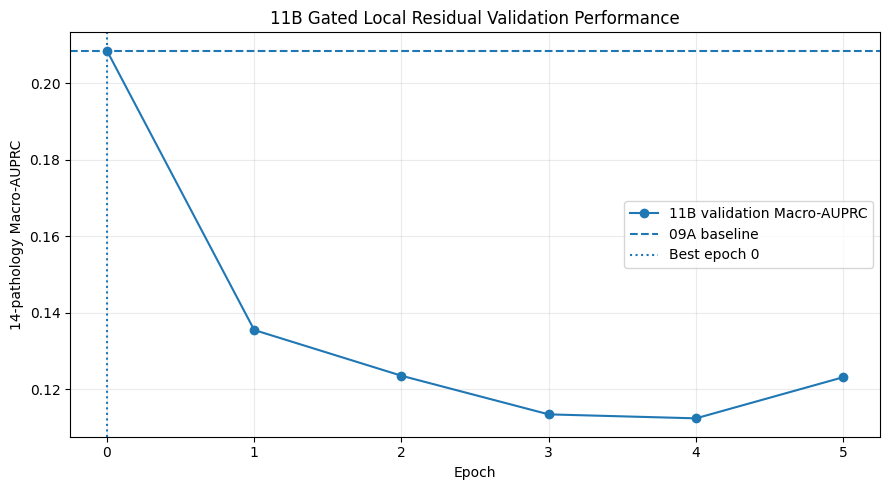

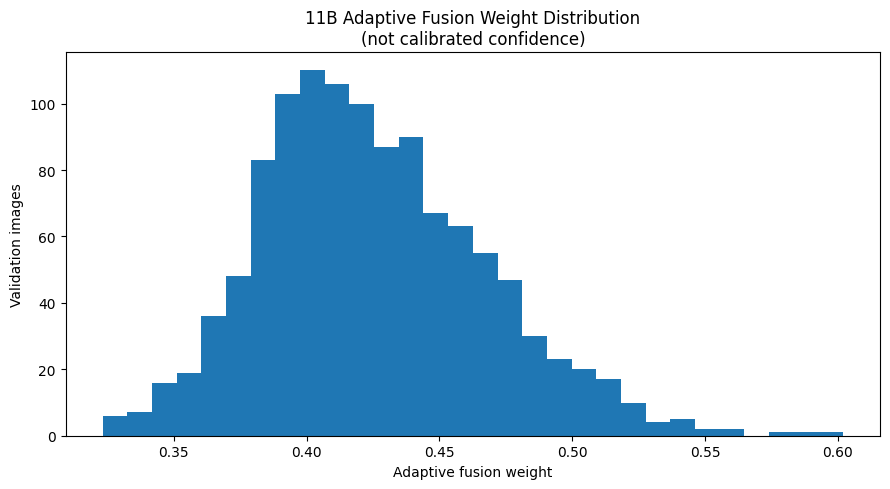

In [28]:
# ============================================================
# 31. Scientific plots — no restricted X-rays
# ============================================================
history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    history_df["epoch"],
    history_df["validation_pathology14_macro_AUPRC"],
    marker="o",
    label="11B validation Macro-AUPRC",
)

ax.axhline(
    baseline_ap,
    linestyle="--",
    label="09A baseline",
)

ax.axvline(
    best_epoch,
    linestyle=":",
    label=f"Best epoch {best_epoch}",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("14-pathology Macro-AUPRC")
ax.set_title("11B Gated Local Residual Validation Performance")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "validation_macro_auprc.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()


fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    final_stats["gate_values"],
    bins=30,
)

ax.set_xlabel("Adaptive fusion weight")
ax.set_ylabel("Validation images")
ax.set_title(
    "11B Adaptive Fusion Weight Distribution\n"
    "(not calibrated confidence)"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "adaptive_fusion_weight_distribution.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()


In [29]:
# ============================================================
# 32. Save config + environment + README
# ============================================================
peak_gpu_memory_gb = (
    torch.cuda.max_memory_allocated() / 1024**3
    if DEVICE.type == "cuda"
    else None
)

config = {
    "experiment_id":
        EXPERIMENT_ID,
    "stage":
        "Pedi_CGAM_Lite_Reliability_Gated_Local_Residual",
    "base_experiment_id":
        BASELINE_EXPERIMENT_ID,
    "localization_experiment_id":
        LOCALIZATION_EXPERIMENT_ID,
    "base_model_frozen":
        True,
    "localization_adapter_frozen":
        True,
    "base_feature_maps_detached":
        True,
    "localization_feature_maps_detached":
        True,
    "fusion_trainable_parameters":
        cgam_trainable,
    "gate_type":
        "image_level_scalar_adaptive_fusion_weight",
    "gate_interpretation":
        "adaptive_fusion_weight_not_calibrated_confidence",
    "reliability_descriptors": [
        "max_abnormal_finding_probability",
        "mean_abnormal_finding_probability",
        "top3_mean_abnormal_finding_probability",
        "aggregate_attention_concentration",
    ],
    "lesion_feature":
        "finding-probability-weighted aggregation of frozen 10E spatial-softmax maps applied to frozen ResNet50 feature map",
    "fusion_equation":
        "final_logits = frozen_09A_logits + gate * LocalResidualHead(LayerNorm(local_feature))",
    "prediction_equation":
        "gate=0 gives exact frozen 09A fallback; local evidence is an optional correction",
    "residual_head_initialization":
        "all zeros so initial 11B predictions exactly equal 09A",
    "epoch0_exact_09A_checkpoint_candidate":
        True,
    "selected_best_epoch":
        int(best_epoch),
    "trained_epoch_selected":
        bool(best_epoch > 0),
    "disease_loss":
        "BinaryFocalLoss",
    "focal_gamma":
        FOCAL_GAMMA,
    "optimizer":
        "AdamW",
    "fusion_learning_rate":
        FUSION_LR,
    "fusion_weight_decay":
        FUSION_WEIGHT_DECAY,
    "selection_metric":
        "validation_14_pathology_macro_AUPRC",
    "image_size":
        IMAGE_SIZE,
    "seed":
        SEED,
    "split_manifest_sha256":
        manifest_hash,
    "calibration_used":
        False,
    "official_test_used":
        False,
    "box_loss_optimized_in_11B":
        False,
    "finding_loss_optimized_in_11B":
        False,
    "numeric_class_id_used":
        False,
}

with open(
    OUTPUT_DIR / "config.json",
    "w",
) as f:
    json.dump(config, f, indent=2)

environment_info = {
    "python": sys.version,
    "platform": platform.platform(),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "pydicom": pydicom.__version__,
    "gpu_name": torch.cuda.get_device_name(0),
    "peak_gpu_memory_gb": peak_gpu_memory_gb,
    "training_seconds": training_seconds,
    "training_minutes": training_seconds / 60,
    "best_epoch": int(best_epoch),
}

with open(
    OUTPUT_DIR / "environment_info.json",
    "w",
) as f:
    json.dump(environment_info, f, indent=2)

head_ap = float(
    final_groups.loc[
        final_groups["group"] == "Head",
        "macro_AUPRC",
    ].iloc[0]
)

middle_ap = float(
    final_groups.loc[
        final_groups["group"] == "Middle",
        "macro_AUPRC",
    ].iloc[0]
)

tail_ap = float(
    final_groups.loc[
        final_groups["group"] == "Tail",
        "macro_AUPRC",
    ].iloc[0]
)

summary_lines = [
    "Pedi-CGAM Lite — M10 Reliability-Gated Local Residual Fusion",
    "=" * 72,
    "",
    "FROZEN INPUTS",
    f"- Global model: {BASELINE_EXPERIMENT_ID}",
    f"- Localization adapter: {LOCALIZATION_EXPERIMENT_ID}",
    "- 09A base trainable: NO",
    "- 10E adapter trainable: NO",
    "",
    "BASELINE 09A",
    (
        "- Disease 14-pathology Macro-AUPRC: "
        f"{baseline_stats['summary']['pathology14_macro_AUPRC']:.6f}"
    ),
    (
        "- Disease Macro-AUROC: "
        f"{baseline_stats['summary']['pathology14_macro_AUROC']:.6f}"
    ),
    "",
    "11B PEDI-CGAM LITE — GATED LOCAL RESIDUAL — GATED LOCAL RESIDUAL",
    (
        "- Disease 14-pathology Macro-AUPRC: "
        f"{final_summary['pathology14_macro_AUPRC']:.6f}"
    ),
    (
        "- Disease Macro-AUROC: "
        f"{final_summary['pathology14_macro_AUROC']:.6f}"
    ),
    (
        "- Disease Macro-F1 @0.5: "
        f"{final_summary['pathology14_macro_F1_at_0.5']:.6f}"
    ),
    (
        "- Macro-AUPRC delta vs 09A: "
        f"{final_summary['pathology14_macro_AUPRC'] - baseline_ap:+.6f}"
    ),
    "",
    "RARITY GROUPS",
    f"- Head AUPRC: {head_ap:.6f}",
    f"- Middle AUPRC: {middle_ap:.6f}",
    f"- Tail AUPRC: {tail_ap:.6f}",
    "",
    "ADAPTIVE FUSION WEIGHT",
    f"- Mean: {final_gate['mean']:.6f}",
    f"- Std: {final_gate['std']:.6f}",
    f"- Median: {final_gate['median']:.6f}",
    f"- 5th–95th percentile: {final_gate['q05']:.6f}–{final_gate['q95']:.6f}",
    "- Interpretation: adaptive fusion weight, NOT calibrated confidence",
    "",
    "FROZEN LOCALIZATION SOURCE",
    (
        "- Attention mass inside boxes: "
        f"{final_stats['localization_summary']['pair_weighted_attention_mass_inside_box']:.6f}"
    ),
    (
        "- Pointing-game accuracy: "
        f"{final_stats['localization_summary']['pair_weighted_pointing_game_accuracy']:.6f}"
    ),
    "",
    "INTEGRITY",
    f"- Frozen 09A hash unchanged: {base_hash_unchanged}",
    f"- Frozen 10E adapter hash unchanged: {adapter_hash_unchanged}",
    (
        "- Max frozen-base probability difference: "
        f"{max_base_probability_difference:.12f}"
    ),
    "- Calibration split used: NO",
    "- Official test used: NO",
    "- Box loss optimized in 11B: NO",
    "- Finding loss optimized in 11B: NO",
    "",
    "TRAINING",
    f"- Best epoch: {best_epoch}",
    f"- Trained epoch selected: {best_epoch > 0}",
    f"- Epoch-0 exact 09A fallback available: YES",
    f"- Trainable CGAM parameters: {cgam_trainable:,}",
    f"- Training time: {training_seconds/60:.2f} minutes",
]

summary_text = "\n".join(summary_lines)

print(summary_text)

with open(
    OUTPUT_DIR / "README_RESULTS.txt",
    "w",
) as f:
    f.write(summary_text)


Pedi-CGAM Lite — M10 Reliability-Gated Local Residual Fusion

FROZEN INPUTS
- Global model: M01_DiseaseFinding_Multitask_Seed42
- Localization adapter: M08_DecoupledLocalizationAdapter_Seed42
- 09A base trainable: NO
- 10E adapter trainable: NO

BASELINE 09A
- Disease 14-pathology Macro-AUPRC: 0.208439
- Disease Macro-AUROC: 0.812544

11B PEDI-CGAM LITE — GATED LOCAL RESIDUAL — GATED LOCAL RESIDUAL
- Disease 14-pathology Macro-AUPRC: 0.208439
- Disease Macro-AUROC: 0.812544
- Disease Macro-F1 @0.5: 0.039380
- Macro-AUPRC delta vs 09A: +0.000000

RARITY GROUPS
- Head AUPRC: 0.223551
- Middle AUPRC: 0.354951
- Tail AUPRC: 0.006408

ADAPTIVE FUSION WEIGHT
- Mean: 0.425009
- Std: 0.042150
- Median: 0.419423
- 5th–95th percentile: 0.362907–0.501186
- Interpretation: adaptive fusion weight, NOT calibrated confidence

FROZEN LOCALIZATION SOURCE
- Attention mass inside boxes: 0.698994
- Pointing-game accuracy: 0.742248

INTEGRITY
- Frozen 09A hash unchanged: True
- Frozen 10E adapter hash unch

In [30]:
# ============================================================
# 33. Final integrity gate
# ============================================================
checks = pd.DataFrame([
    {
        "check": "Frozen split SHA-256 verified",
        "passed":
            manifest_hash
            == EXPECTED_SPLIT_MANIFEST_SHA256,
    },
    {
        "check": "Train count = 5,408",
        "passed": len(train_df) == 5408,
    },
    {
        "check": "Validation count = 1,159",
        "passed": len(val_df) == 1159,
    },
    {
        "check": "09A checkpoint verified",
        "passed":
            m01_checkpoint.get("experiment_id")
            == BASELINE_EXPERIMENT_ID,
    },
    {
        "check": "10E adapter checkpoint verified",
        "passed":
            m08_checkpoint.get("experiment_id")
            == LOCALIZATION_EXPERIMENT_ID,
    },
    {
        "check": "09A disease metric reproduced",
        "passed":
            abs(
                baseline_ap
                - EXPECTED_M01_PATHOLOGY14_AUPRC
            )
            <= M01_REPRO_TOLERANCE,
    },
    {
        "check": "CGAM starts exactly from 09A logits",
        "passed":
            initial_max_logit_difference
            <= 1e-8,
    },
    {
        "check": "09A has 0 trainable parameters",
        "passed": base_trainable == 0,
    },
    {
        "check": "10E adapter has 0 trainable parameters",
        "passed": adapter_trainable == 0,
    },
    {
        "check": "CGAM has trainable parameters",
        "passed": cgam_trainable > 0,
    },
    {
        "check": "Frozen 09A hash unchanged",
        "passed": base_hash_unchanged,
    },
    {
        "check": "Frozen 10E adapter hash unchanged",
        "passed": adapter_hash_unchanged,
    },
    {
        "check": "Frozen 09A probabilities unchanged",
        "passed":
            max_base_probability_difference
            <= 1e-7,
    },
    {
        "check": "CGAM disease Macro-AUPRC finite",
        "passed":
            np.isfinite(
                final_summary[
                    "pathology14_macro_AUPRC"
                ]
            ),
    },
    {
        "check": "Gate values finite",
        "passed":
            np.isfinite(
                final_stats["gate_values"]
            ).all(),
    },
    {
        "check": "Gate values lie in [0,1]",
        "passed":
            (
                final_stats["gate_values"] >= 0
            ).all()
            and (
                final_stats["gate_values"] <= 1
            ).all(),
    },
    {
        "check": "11B selected metric is not below epoch-0 baseline",
        "passed":
            final_summary[
                "pathology14_macro_AUPRC"
            ]
            >= baseline_ap - 1e-10,
    },
    {
        "check": "Selected checkpoint records exact fallback design",
        "passed":
            best_checkpoint.get(
                "epoch0_exact_09A_fallback"
            ) is True,
    },
    {
        "check": "Calibration data not used",
        "passed": True,
    },
    {
        "check": "Official test not used",
        "passed": True,
    },
    {
        "check": "No preprocessing failures",
        "passed":
            len(cache_failures) == 0,
    },
])

checks["status"] = checks["passed"].map({
    True: "PASS",
    False: "REVIEW",
})

display(checks)

checks.to_csv(
    OUTPUT_DIR / "final_integrity_status.csv",
    index=False,
)

FINAL_STATUS = (
    "PASS"
    if checks["passed"].all()
    else "REVIEW"
)

print(
    "\nM10 PEDI-CGAM LITE GATED LOCAL RESIDUAL FINAL STATUS:",
    FINAL_STATUS,
)

if FINAL_STATUS == "PASS":
    print(
        "✅ M10 PEDI-CGAM LITE GATED LOCAL RESIDUAL EXPERIMENT COMPLETED SUCCESSFULLY"
    )
else:
    print(
        "⚠️ REVIEW BEFORE CONTINUING"
    )


,check,passed,status
0,Frozen split SHA-256 verified,True,PASS
1,"Train count = 5,408",True,PASS
2,"Validation count = 1,159",True,PASS
3,09A checkpoint verified,True,PASS
4,10E adapter checkpoint verified,True,PASS
5,09A disease metric reproduced,True,PASS
6,CGAM starts exactly from 09A logits,True,PASS
7,09A has 0 trainable parameters,True,PASS
8,10E adapter has 0 trainable parameters,True,PASS
9,CGAM has trainable parameters,True,PASS



M10 PEDI-CGAM LITE GATED LOCAL RESIDUAL FINAL STATUS: PASS
✅ M10 PEDI-CGAM LITE GATED LOCAL RESIDUAL EXPERIMENT COMPLETED SUCCESSFULLY


# 34. Export rule

The ZIP includes:

- CGAM fusion checkpoint;
- disease metrics;
- validation probabilities;
- adaptive fusion weights;
- reliability descriptors;
- frozen localization audit;
- configuration;
- training history;
- scientific plots;
- integrity checks.

The ZIP does **not** include:

- DICOM files;
- cached `.npy` images;
- raw X-rays;
- raw box masks;
- raw bounding-box coordinate tables.


In [31]:
# ============================================================
# 35. Package complete M09 output
# ============================================================
ZIP_FILE = Path(
    "/kaggle/working/"
    "M10_PediCGAMLite_GatedLocalResidual_Seed42_All_Outputs.zip"
)

if ZIP_FILE.exists():
    ZIP_FILE.unlink()

source_files = sorted(
    p
    for p in OUTPUT_DIR.rglob("*")
    if p.is_file()
)

if not source_files:
    raise RuntimeError(
        "No M10 experiment outputs were found."
    )

blocked_extensions = {
    ".dcm",
    ".dicom",
    ".npy",
    ".npz",
}

for p in source_files:
    if p.suffix.lower() in blocked_extensions:
        raise RuntimeError(
            "STOP: restricted/raw file detected in output folder: "
            + str(p)
        )

with zipfile.ZipFile(
    ZIP_FILE,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6,
) as zf:
    for p in source_files:
        arcname = (
            Path(EXPERIMENT_ID)
            / p.relative_to(OUTPUT_DIR)
        )

        zf.write(
            p,
            arcname=str(arcname),
        )

with zipfile.ZipFile(ZIP_FILE, "r") as zf:
    corrupt_entry = zf.testzip()
    archive_names = zf.namelist()

if corrupt_entry is not None:
    raise RuntimeError(
        "ZIP integrity failure: "
        + str(corrupt_entry)
    )

required_outputs = [
    "best_cgam_fusion.pth",
    "config.json",
    "environment_info.json",
    "training_history.csv",
    "09A_vs_11B_comparison.csv",
    "cgam_disease_per_class.csv",
    "cgam_head_middle_tail.csv",
    "validation_gate_summary.csv",
    "validation_gate_reliability.csv",
    "gate_reliability_correlations.csv",
    "validation_predictions_and_gate.csv",
    "final_integrity_status.csv",
    "README_RESULTS.txt",
]

missing_outputs = [
    name
    for name in required_outputs
    if not any(
        x.endswith("/" + name)
        for x in archive_names
    )
]

if missing_outputs:
    raise RuntimeError(
        "ZIP is missing required outputs: "
        + str(missing_outputs)
    )

print(
    "✅ M10 COMPLETE OUTPUT ZIP CREATED"
)
print("File:", ZIP_FILE)
print(
    "ZIP size:",
    f"{ZIP_FILE.stat().st_size/(1024**2):.2f} MB",
)
print("ZIP integrity: PASS")
print("Raw DICOM/cache files included: NO")


✅ M10 COMPLETE OUTPUT ZIP CREATED
File: /kaggle/working/M10_PediCGAMLite_GatedLocalResidual_Seed42_All_Outputs.zip
ZIP size: 4.08 MB
ZIP integrity: PASS
Raw DICOM/cache files included: NO


## What to send back

After the run finishes, send:

`M10_PediCGAMLite_GatedLocalResidual_Seed42_All_Outputs.zip`

I will check:

- whether any trained epoch beats the explicit epoch-0 09A baseline;
- 14-pathology Macro-AUPRC and Macro-AUROC;
- Head / Middle / Tail behavior;
- per-class gains/losses;
- adaptive fusion-weight distribution;
- whether the gate remains non-trivial;
- reliability-descriptor associations;
- frozen 09A / 10E integrity.

### Decision rule

- If a **trained epoch** beats 09A while using the local branch meaningfully, 11B becomes the leading CGAM candidate.
- If **epoch 0 remains best**, then the current local correction does not add disease-discrimination value and we should not force CGAM as the central claim.

The gate is still an **adaptive fusion weight / reliability signal**, not calibrated confidence. Calibration remains a later held-out step.
